# 🎬 Pipeline Completo de NLP: Classificação de Sentimento com TensorFlow/Keras

**Objetivo:** Projetar, calibrar e avaliar uma rede neural profunda para mineração de opinião e processamento de linguagem natural (NLP), identificando automaticamente se uma crítica cinematográfica expressa uma opinião **Favorável (Positiva)** ou **Desfavorável (Negativa)**.

*Da representação vetorial à extração semântica: transformando palavras em probabilidades matematicamente calculadas.* 🚀

### 1. Contexto e Origem do Corpus

Utilizaremos o clássico benchmark **IMDB Large Movie Review Dataset**, disponibilizado pelo ecossistema Keras.
* **Volume:** 50.000 avaliações de cinema em língua inglesa com forte carga opinativa.
* **Divisão:** 25.000 instâncias reservadas para o ajuste de pesos (treinamento) e 25.000 instâncias retidas para validação cega (teste).
* **Distribuição:** Conjunto perfeitamente balanceado (50% de resenhas positivas e 50% de negativas).

In [ ]:
# Importando o necessário
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing import sequence
import matplotlib.pyplot as plt
import numpy as np

### 2. Ingestão e Delimitação do Vocabulário

Filtraremos as 10.000 palavras mais recorrentes do vocabulário para evitar ruídos de termos raros (outliers léxicos) e otimizar a convergência do modelo.

In [ ]:
# Hiperparâmetros de vocabulário e tamanho de sequência
max_features = 10000
max_len = 250

# Carrega o dataset IMDB - Já está embutido no Keras!
(x_treino, y_treino), (x_teste, y_teste) = datasets.imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Classes dos sentimentos
nomes_classes = ['Negativo', 'Positivo']

### 3. Normalização Estrutural (Padding e Truncamento)

Redes neurais que processam lotes de tensores exigem matrizes de formato fixo. Resenhas muito longas serão truncadas e resenhas menores receberão preenchimento com zeros (`<PAD>`).

In [ ]:
# Padroniza os vetores de inteiros para que todos tenham o mesmo tamanho (max_len)
x_treino = sequence.pad_sequences(x_treino, maxlen=max_len)
x_teste = sequence.pad_sequences(x_teste, maxlen=max_len)

### 4. Inspeção e Decodificação de Amostra

Para auditar o que a rede recebe, reconstruímos os identificadores numéricos na sentença correspondente original através do dicionário léxico do dataset.

In [ ]:
# Mapeamento para decodificar números de volta para palavras
word_index = datasets.imdb.get_word_index()
reverse_word_index = {v + 3: k for k, v in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decodifica_review(text_indices):
    return ' '.join([reverse_word_index.get(i, '?') for i in text_indices if i != 0])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 5. Arquitetura Neural: Convolução 1D para Texto

Projetamos uma rede que aprende representações densas de palavras (**Embedding**) e utiliza blocos convolucionais unidimensionais (**Conv1D**) capazes de capturar n-gramas e contextos locais ao longo da sequência textual.

In [ ]:
# Visualiza uma resenha de treino e seu respectivo rótulo
print("Rótulo:", nomes_classes[y_treino[0]])
print("Texto:", decodifica_review(x_treino[0])[:300], "...")

Rótulo: Positivo
Texto: <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the ...


In [ ]:
# Arquitetura do Modelo -> Feature Learning em Texto
modelo_imdb = models.Sequential()
modelo_imdb.add(layers.Input(shape=(max_len,)))

# Camada de Embedding (converte índices de palavras em vetores densos)
modelo_imdb.add(layers.Embedding(input_dim=max_features, output_dim=64))

# Camadas de convolução temporal e pooling
modelo_imdb.add(layers.Conv1D(64, 5, activation='relu'))
modelo_imdb.add(layers.MaxPooling1D(pool_size=4))

modelo_imdb.add(layers.Conv1D(64, 5, activation='relu'))
modelo_imdb.add(layers.GlobalMaxPooling1D())

In [ ]:
# Adicionar camadas densas de classificação
modelo_imdb.add(layers.Dense(64, activation='relu'))
modelo_imdb.add(layers.Dropout(0.5))
modelo_imdb.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
# Compilação do modelo
modelo_imdb.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### 6. Execução do Ciclo de Treinamento

Iniciamos o ajuste de pesos ao longo de 5 épocas com mini-batches de 64 amostras, medindo a perda e a acurácia simultaneamente no conjunto de validação cego.

In [ ]:
# Executando o treinamento
%%time
history = modelo_imdb.fit(
    x_treino,
    y_treino,
    epochs=5,
    batch_size=64,
    validation_data=(x_teste, y_teste)
)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 114ms/step - accuracy: 0.6812 - loss: 0.5459 - val_accuracy: 0.8515 - val_loss: 0.3393
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.8893 - loss: 0.2834 - val_accuracy: 0.8553 - val_loss: 0.3350
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.9377 - loss: 0.1741 - val_accuracy: 0.8502 - val_loss: 0.3807
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - accuracy: 0.9677 - loss: 0.0999 - val_accuracy: 0.8576 - val_loss: 0.4502
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - accuracy: 0.9849 - loss: 0.0478 - val_accuracy: 0.8506 - val_loss: 0.5631
CPU times: user 5min 43s, sys: 4.04 s, total: 5min 47s
Wall time: 4min 19s


Treinamento concluído com sucesso! 💪 Observe se ao final de cada época a acurácia aumenta.

**Previsão - Testar o modelo (Deploy)**

Testar o modelo treinado com uma resenha em texto livre inédita. Convertemos o texto para os índices correspondentes e emitimos a classificação.

In [ ]:
# Nova avaliação para inferência
nova_review = "this movie was fantastic brilliant acting and incredible plot"

# Converte as palavras para índices usando o dicionário oficial do IMDB
palavras = nova_review.lower().split()
indices = [1]  # Marcação <START>
for palavra in palavras:
    idx = word_index.get(palavra, 2 - 3) + 3
    indices.append(idx if idx < max_features else 2)

# Aplica padding
nova_review_array = sequence.pad_sequences([indices], maxlen=max_len)

In [ ]:
# Fazendo a previsão!
previsao = modelo_imdb.predict(nova_review_array)
print("Probabilidade predita:", previsao)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Probabilidade predita: [[0.9986624]]


In [ ]:
# Obtém a classe com base no limiar de 0.5
classe_prevista = int(previsao[0][0] >= 0.5)
nome_classe_prevista = nomes_classes[classe_prevista]

print("A nova avaliação foi classificada como:", nome_classe_prevista)

A nova avaliação foi classificada como: Positivo


**Avaliação do Desempenho e Curvas de Aprendizado**

Análise quantitativa do modelo no conjunto de teste e visualização gráfica da acurácia e perda ao longo das épocas.

Perda no Teste: 0.5631
Acurácia no Teste: 85.06%


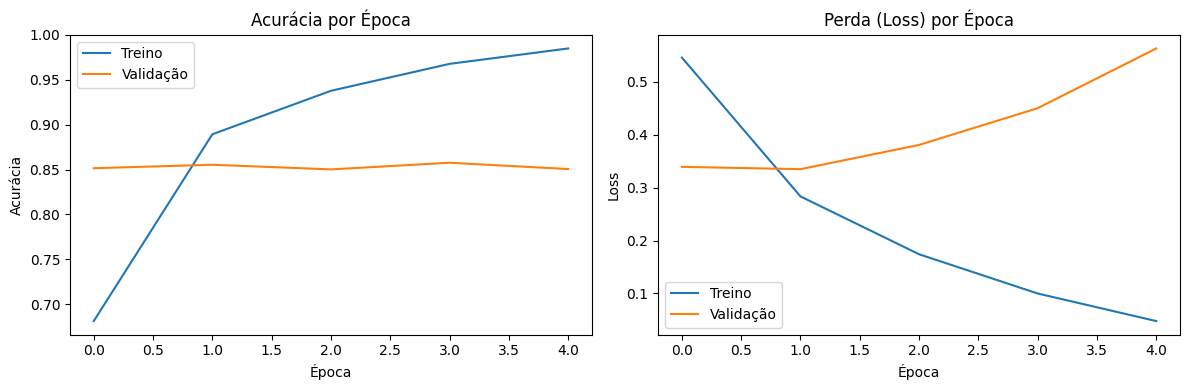

In [ ]:
# Avaliação quantitativa no conjunto de teste
perda_teste, acuracia_teste = modelo_imdb.evaluate(x_teste, y_teste, verbose=0)
print(f"Perda no Teste: {perda_teste:.4f}")
print(f"Acurácia no Teste: {acuracia_teste * 100:.2f}%")

# Gráfico de Acurácia e Perda
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Perda (Loss) por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Matriz de Confusão e Relatório de Métricas**

Verificação detalhada dos acertos e erros do modelo entre avaliações positivas e negativas.

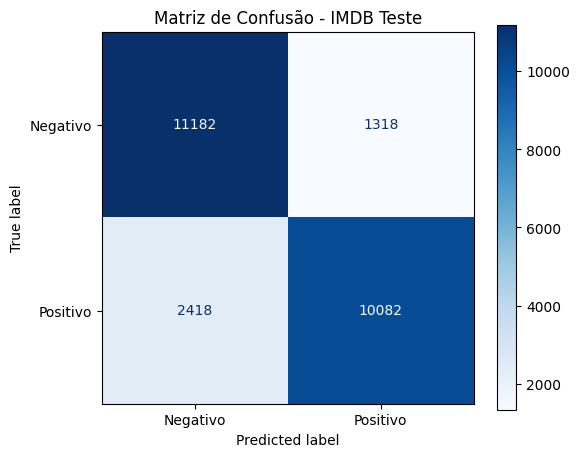


Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.82      0.89      0.86     12500
    Positivo       0.88      0.81      0.84     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predições para toda a base de teste
probabilidades_teste = modelo_imdb.predict(x_teste, batch_size=128, verbose=0)
predicoes_teste = (probabilidades_teste >= 0.5).astype(int).flatten()

# Matriz de Confusão
matriz = confusion_matrix(y_teste, predicoes_teste)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=nomes_classes)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão - IMDB Teste')
plt.grid(False)
plt.show()

# Relatório de Classificação Detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_teste, predicoes_teste, target_names=nomes_classes))

**Testes com Reviews Reais: Homem-Aranha: Sem Volta Para Casa (Spider-Man: No Way Home)**

Inferência com críticas reais em inglês retiradas do IMDB (positiva e negativa) sobre o filme do Homem-Aranha.

In [ ]:
import re

# Função de higienização, tokenização e inferência
def classificar_review(texto):
    texto_limpo = re.sub(r'[^a-zA-Z\s]', '', texto.lower())
    palavras = texto_limpo.split()

    indices = [1]  # Marcação <START>
    for palavra in palavras:
        idx = word_index.get(palavra, 2 - 3) + 3
        indices.append(idx if idx < max_features else 2)  # 2 = <UNK> (palavra fora do vocabulário)

    vetor_pad = sequence.pad_sequences([indices], maxlen=max_len)
    probabilidade = modelo_imdb.predict(vetor_pad, verbose=0)[0][0]
    classe = int(probabilidade >= 0.5)

    return probabilidade, nomes_classes[classe]

# Lista de avaliações não rotuladas sobre Spider-Man: Brand New Day
reviews_spiderman_brand_new_day = [
    "Spider-Man Brand New Day is exactly the fresh start Peter Parker needed. Tom Holland delivers a mature, grounded and deeply emotional performance, back in New York City with incredible street-level action.",
    "A massive disappointment. Brand New Day has a boring narrative, horrible pacing, and completely throws away Peter's development with forced drama and dull villains.",
    "The swinging scenes look visually stunning and the raw physical combat in the streets was fantastic. It feels like classic comic book Spider-Man finally brought to life on the big screen.",
    "The plot was a convoluted mess. The emotional core fell totally flat and the dialogue felt uninspired and poorly written throughout the entire two hours.",
    "An extraordinary return to form! The bittersweet tone of Peter dealing with his solitude while protecting the city creates one of the best superhero movies in years.",
    "Felt rushed and lifeless. Overhyped marketing for a generic movie that fails to deliver any real excitement or memorable moments."
]

# Processamento e classificação automática do lote
print("=================================================================")
print("  CLASSIFICAÇÃO AUTOMÁTICA: SPIDER-MAN: BRAND NEW DAY (2026)")
print("=================================================================\n")

for i, review in enumerate(reviews_spiderman_brand_new_day, 1):
    prob, rotulo = classificar_review(review)
    print(f"[{i}] Avaliação:")
    print(f"\"{review}\"")
    print(f"➡️ Sentimento Predito: {rotulo.upper()} | Confiança: {prob * 100:.2f}%\n" if rotulo == 'Positivo'
          else f"➡️ Sentimento Predito: {rotulo.upper()} | Confiança: {(1 - prob) * 100:.2f}%\n")

  CLASSIFICAÇÃO AUTOMÁTICA: SPIDER-MAN: BRAND NEW DAY (2026)

[1] Avaliação:
"Spider-Man Brand New Day is exactly the fresh start Peter Parker needed. Tom Holland delivers a mature, grounded and deeply emotional performance, back in New York City with incredible street-level action."
➡️ Sentimento Predito: POSITIVO | Confiança: 74.54%

[2] Avaliação:
"A massive disappointment. Brand New Day has a boring narrative, horrible pacing, and completely throws away Peter's development with forced drama and dull villains."
➡️ Sentimento Predito: NEGATIVO | Confiança: 100.00%

[3] Avaliação:
"The swinging scenes look visually stunning and the raw physical combat in the streets was fantastic. It feels like classic comic book Spider-Man finally brought to life on the big screen."
➡️ Sentimento Predito: POSITIVO | Confiança: 99.95%

[4] Avaliação:
"The plot was a convoluted mess. The emotional core fell totally flat and the dialogue felt uninspired and poorly written throughout the entire two hours

Fim! 🔥